# Resolution — where one scalar per region is misleading

The pipeline reduces each scope region's bank to **one scalar**: a single distance perpendicular to the centreline at its middle. This notebook finds the regions where that hurts most, shows the consequence for the predicted 2027 bank line, and shows how R=2 (two per-half scalars) fixes it — without retraining anything.

**Detector**: per survey, split the line samples at the centreline midpoint and compare each half's median distance. A candidate has the halves disagreeing by ≥10 m on ≥3 surveys with a consistent sign — a *persistent* along-channel gradient, not noise. Far-bank suspects are excluded (that is a data problem, not a resolution problem).

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

from src.erosion.region_inspector import RegionInspector

ri = RegionInspector()

In [2]:
cand = ri.resolution_candidates()
print(f'{len(cand)} of {ri.line_stats.location_id.nunique()} measurable '
      'regions have a persistent >=10 m half-vs-half disagreement')
cand.head(20).round(2)

1017 of 11517 measurable regions have a persistent >=10 m half-vs-half disagreement


,n_dates,median_gap_m,consistency,model
location_id,,,,
rijn_r_8780_8790,4,107.95,1.00,segmentation
rijn_r_9910_9920,4,-80.90,1.00,segmentation
rijn_r_9970_9980,4,70.66,1.00,segmentation
rijn_l_8070_8080,5,-63.41,1.00,segmentation
nederrijn_r_5240_5250,6,-61.77,0.83,segmentation
nederrijn_r_3620_3630,7,-57.70,1.00,segmentation
rijn_l_8670_8680,3,57.46,1.00,segmentation
nederrijn_l_3350_3360,7,-57.43,1.00,segmentation
rijn_l_9210_9220,3,54.48,1.00,segmentation


## Top 20, side by side
Dashed = the 2027 line as R=1 draws it (one scalar, with the perpendicular measurement arrow). Solid = R=2, each half anchored on its own latest observed bank and moved by the same regional velocity.

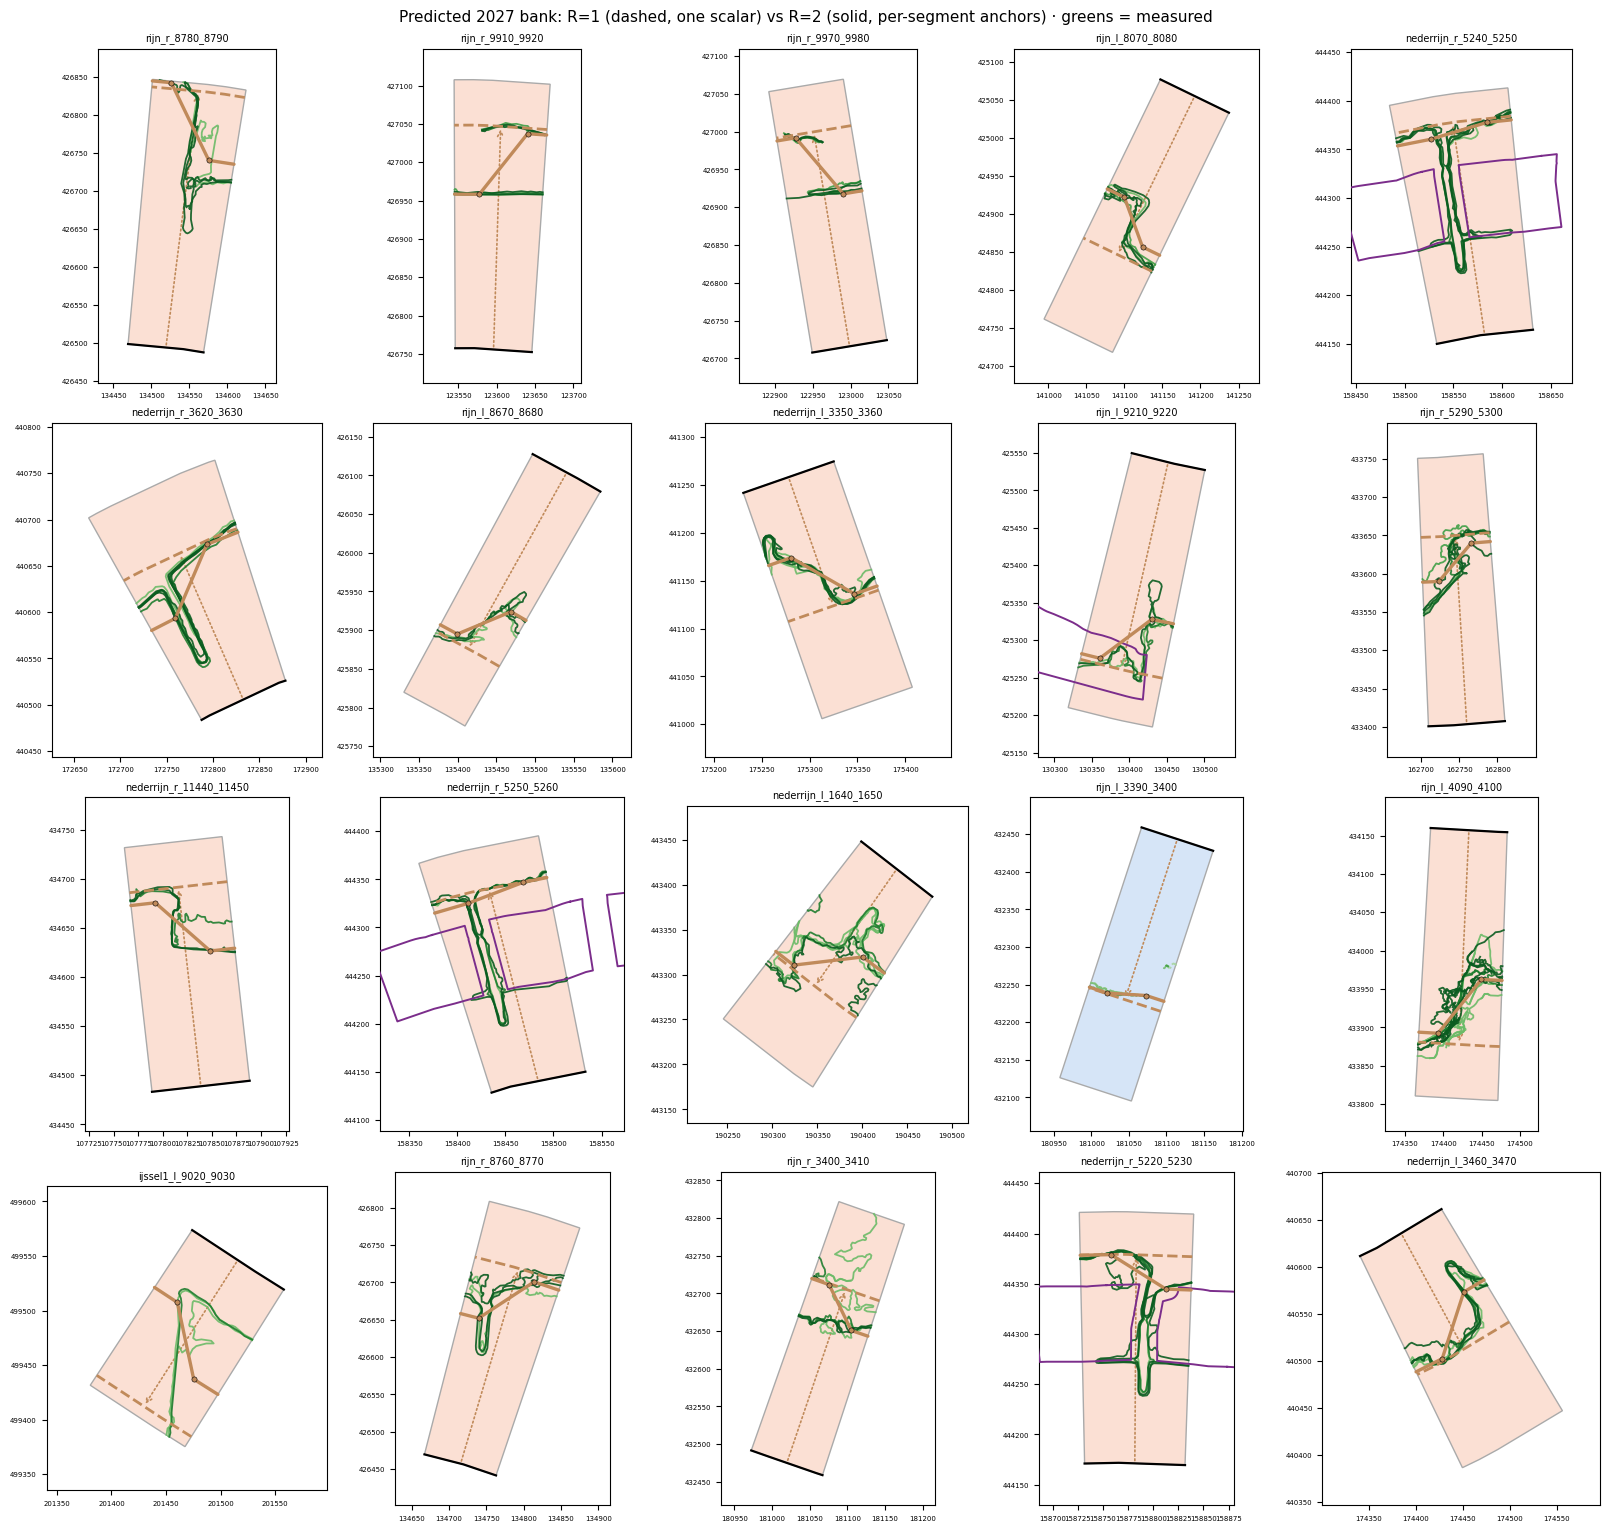

In [3]:
top20 = list(cand.index[:20])
fig = ri.resolution_grid(top20)
plt.show()

## Three champions
In each: for one half of the region the R=1 line hangs where no bank has ever been observed; the R=2 halves land on their own banks. The along-channel step is stable across every survey, so this is real geometry (an inlet, a groyne field, a harbour mouth), not measurement noise.

The R>1 prediction is drawn as a **stitched polyline** through the segment anchors (dots), with the ends running parallel with the centreline to the region border (`end_style='open'` stops at the outermost anchors instead). Note `rijn_r_9910_9920` was dropped from the champions: it scores high but is a *two-waterline* region (the De Avelingen strip), so its story is the far-bank family, not resolution.

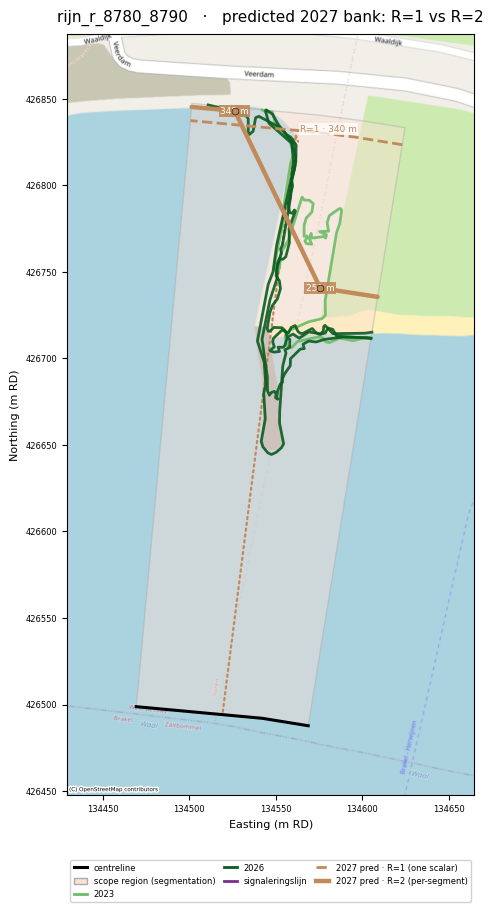

In [4]:
fig = ri.inspect_resolution('rijn_r_8780_8790')
plt.show()

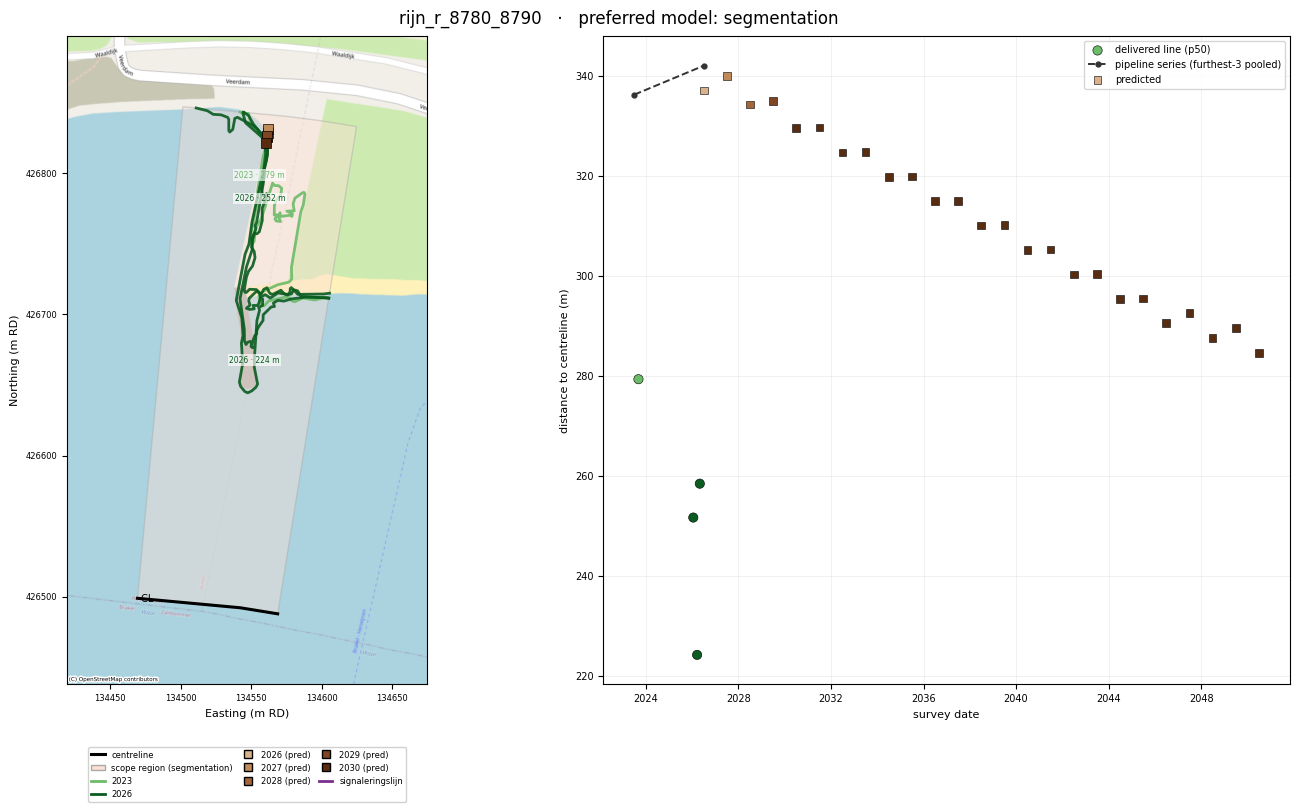

In [5]:
fig = ri.inspect('rijn_r_8780_8790')
plt.show()

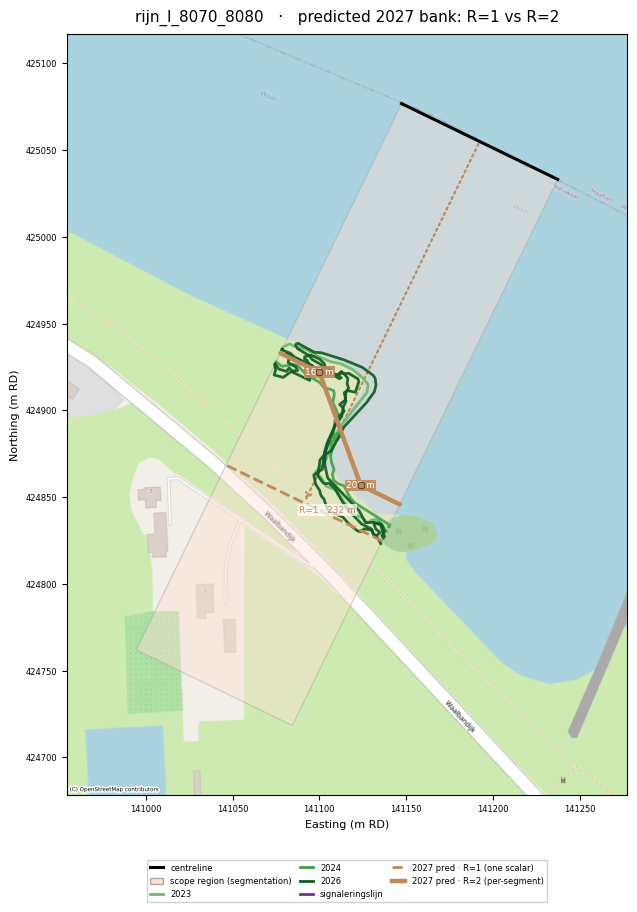

In [6]:
fig = ri.inspect_resolution('rijn_l_8070_8080')
plt.show()

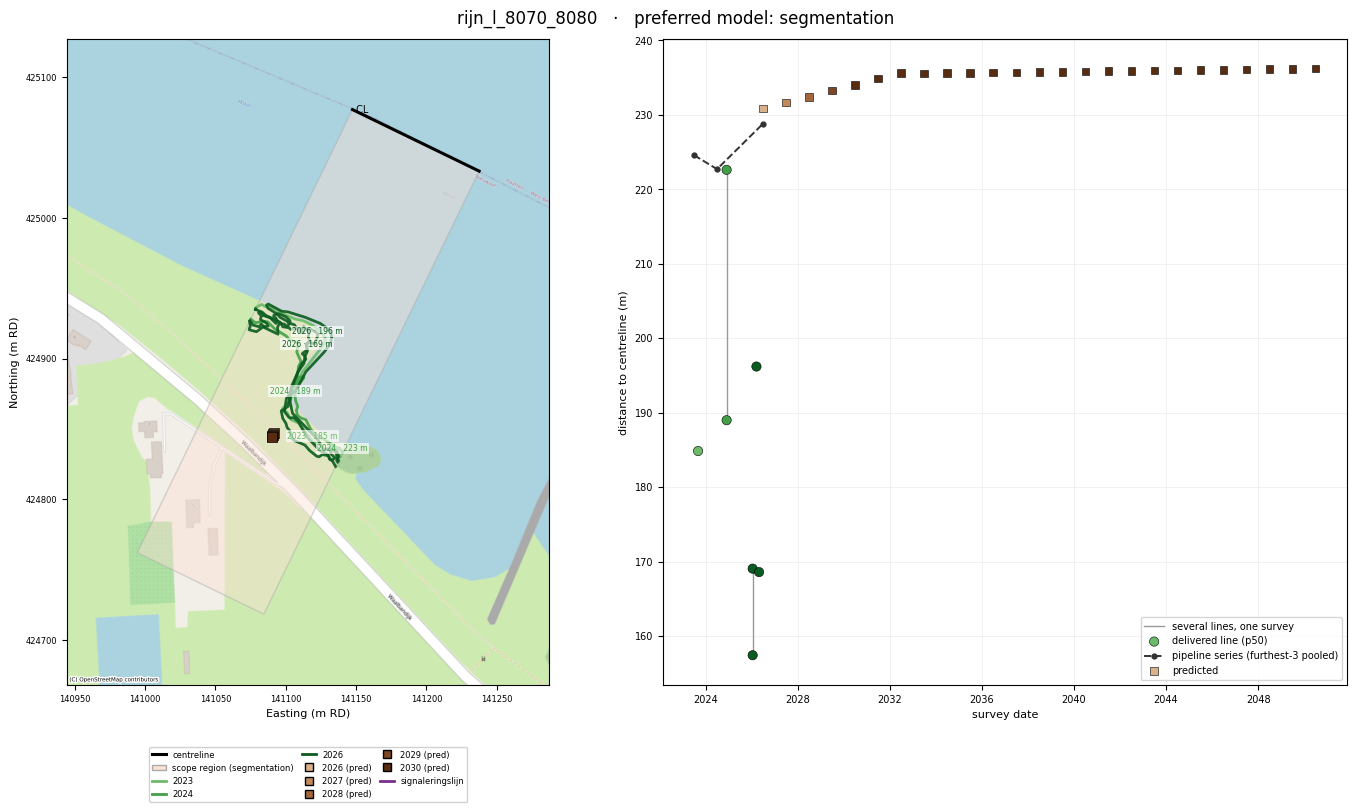

In [7]:
fig = ri.inspect('rijn_l_8070_8080')
plt.show()

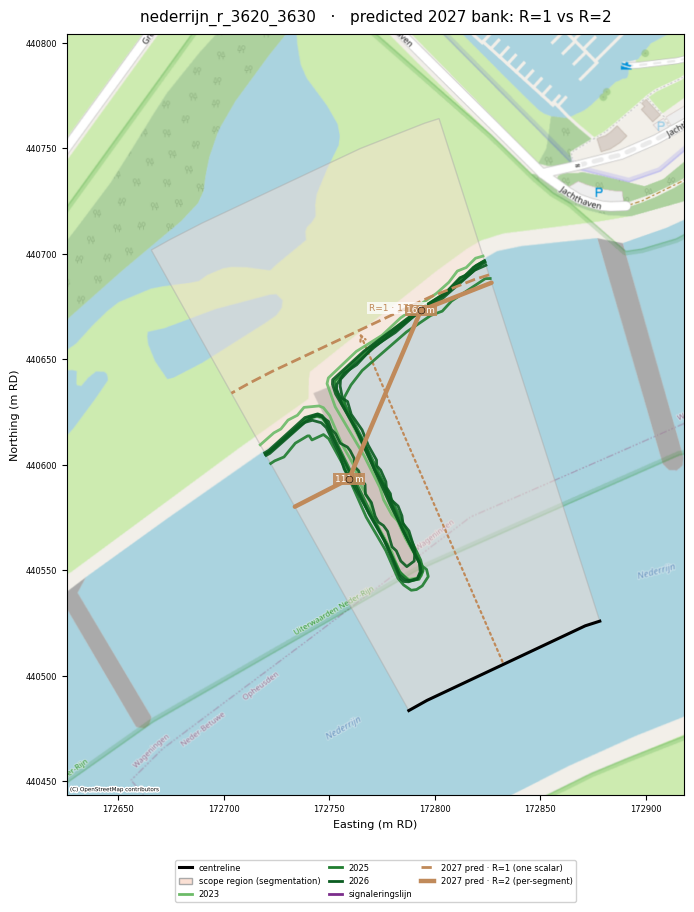

In [8]:
fig = ri.inspect_resolution('nederrijn_r_3620_3630')
plt.show()

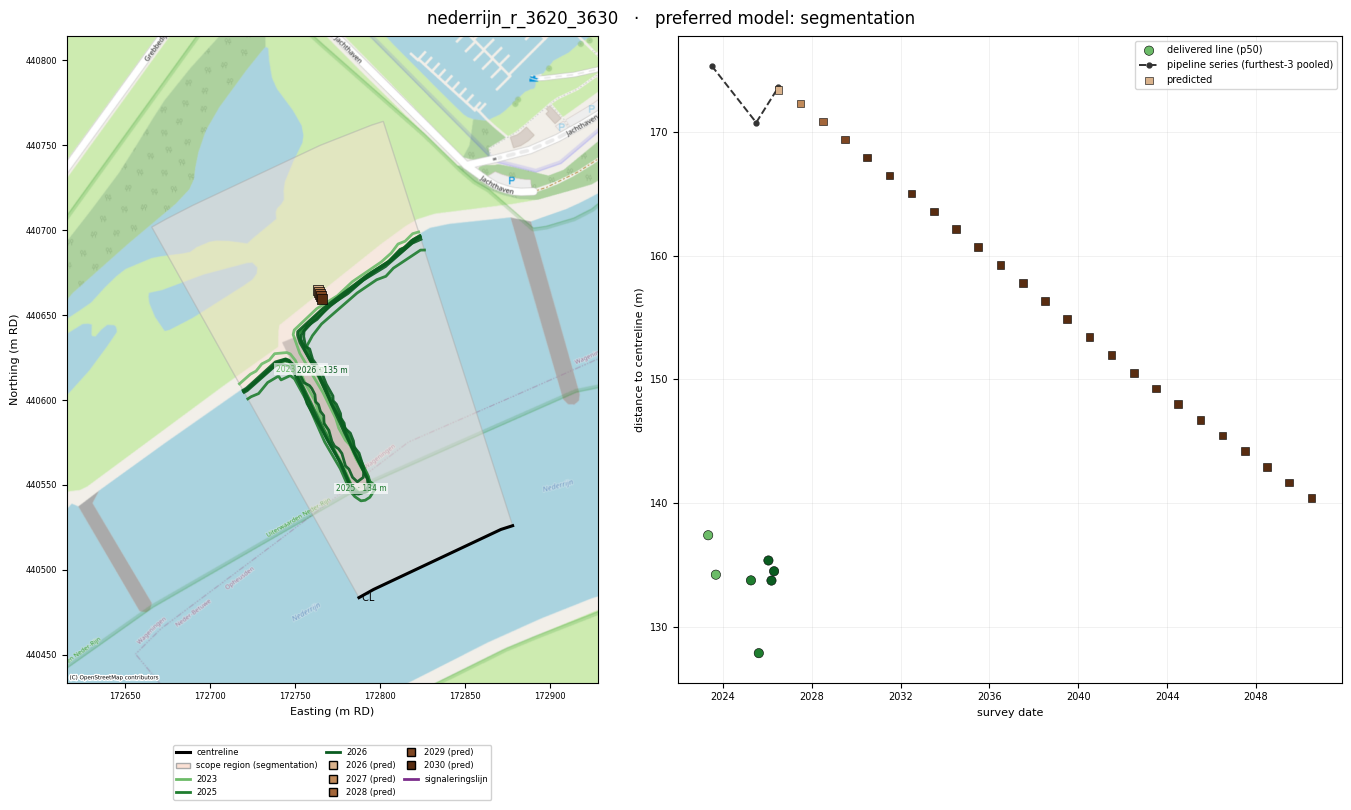

In [9]:
fig = ri.inspect('nederrijn_r_3620_3630')
plt.show()

## Increasing the resolution
The same region at R=2, 5 and 10: the stitched prediction converges on the actual bank shape. Two honest limits: a station-indexed polyline cannot represent a bank that doubles back on itself (the hook at R=10), and thinner segments mean fewer samples per anchor, so noise per anchor grows as R does.

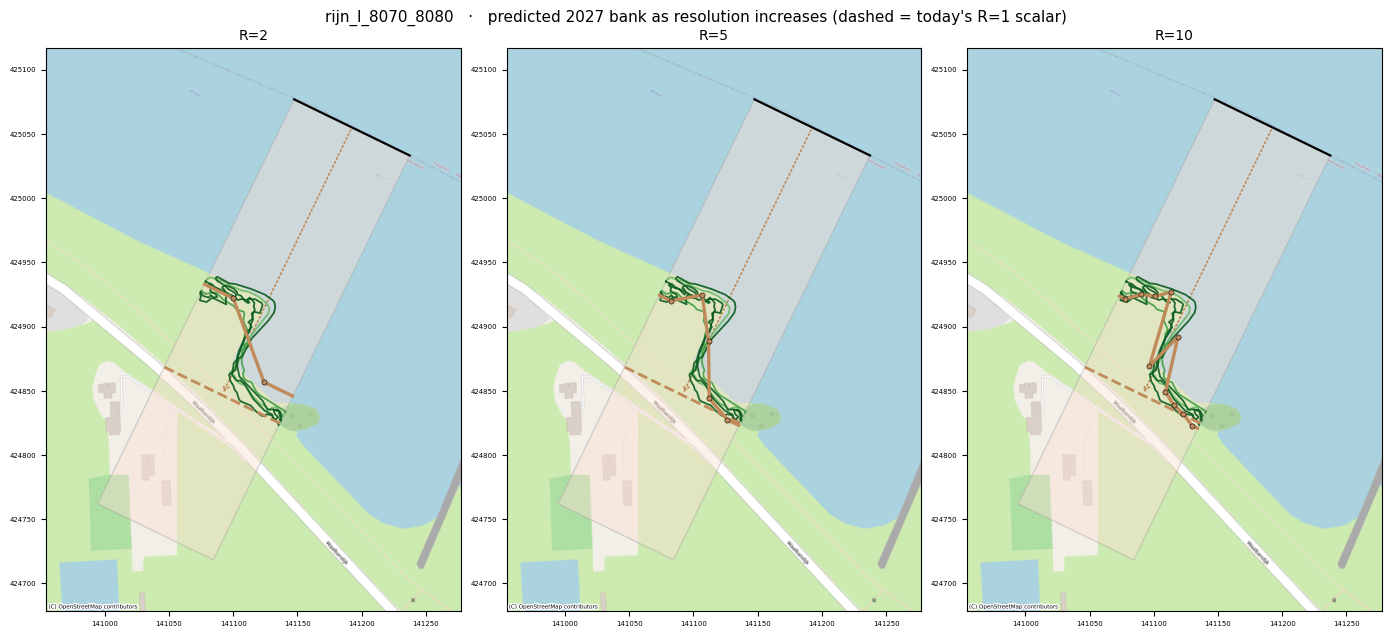

In [10]:
fig = ri.resolution_progression('rijn_l_8070_8080')
plt.show()

## How resolution should enter the pipeline

**Measured linestrings** — the observation unit becomes *(region × segment)*. Every sampled point on a delivered line already knows its station (projection onto the centreline, 0–1); a segment's distance is the median of its own samples per survey. Outliers stay confined to their segment instead of dragging the furthest-3 selection for the whole region, and the far-bank line filter happens *before* this, at line level.

**Predicted linestrings** — the trained model keeps predicting a regional velocity; each segment applies it to its **own** anchor (this notebook, R=2, no retraining). The predicted bank for year Y is then a stitched polyline of per-segment offsets rather than one parallel line — at high R this approximates the actual bank shape. VVR crossing is evaluated per segment and the region's crossing year is the earliest of its segments, which removes the current furthest-bank-vs-nearest-VVR mismatch. Model-level R (per-segment velocities trained on per-segment histories) is the step after, and requires the grouped-by-region split first (segments of one region are near-clones; a random split would leak).
